In [21]:
import sys
!{sys.executable} -m pip install textblob
!{sys.executable} -m textblob.download_corpora


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\gk298\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gk298\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gk298\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\gk298\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\gk298\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\gk298\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

Importing Libraries

In [ ]:
### For loading the datasets and using the dataframes
import pandas as pd
import numpy as np

### For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

### For building the model
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity

# User-Based Filtering
from scipy.sparse import csr_matrix

# For API Requests
import requests

# Sentiment analysis
from textblob import TextBlob

# Tmbd Integration
from PIL import Image
from io import BytesIO

from scipy.sparse import csr_matrix

from IPython.display import display, HTML

Importing Datasets

In [23]:
movies = pd.read_csv(r'C:\Users\gk298\OneDrive\Desktop\Movie Recommendation System\Dataset\movie.csv')
ratings = pd.read_csv(r'C:\Users\gk298\OneDrive\Desktop\Movie Recommendation System\Dataset\rating.csv')
tags = pd.read_csv(r'C:\Users\gk298\OneDrive\Desktop\Movie Recommendation System\Dataset\tag.csv')
links = pd.read_csv(r'C:\Users\gk298\OneDrive\Desktop\Movie Recommendation System\Dataset\link.csv')

print(f"Movies    : {movies.shape}")
print(f"Ratings   : {ratings.shape}")
print(f"Tags      : {tags.shape}")
print(f"Links     : {links.shape}")

Movies    : (27278, 3)
Ratings   : (20000263, 4)
Tags      : (465564, 4)
Links     : (27278, 3)


Basic Data Exploration

In [24]:
print("--- Movies ---")
display(movies.head())

print("\n--- Ratings ---")
display(ratings.head())

print("\n--- Tags ---")
display(tags.head())

print("\n--- Links ---")
display(links.head())

--- Movies ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



--- Ratings ---


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40



--- Tags ---


,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18



--- Links ---


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


Data Cleaning

In [25]:
#checking missing values
print("\n--- Movies ---")
print(movies.isnull().sum())

print("\n--- Ratings ---")
print(ratings.isnull().sum())

print("\n--- Tags ---")
print(tags.isnull().sum())

print("\n--- Links ---")
print(links.isnull().sum())


--- Movies ---
movieId    0
title      0
genres     0
dtype: int64

--- Ratings ---
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

--- Tags ---
userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

--- Links ---
movieId      0
imdbId       0
tmdbId     252
dtype: int64


In [26]:
#handling missing values
tags.dropna(subset=['tag'], inplace=True)

links['tmdbId'] = links['tmdbId'].fillna(0).astype(int)

In [27]:
#checking for duplicates
print(f"Movies  : {movies.duplicated().sum()}")
print(f"Ratings : {ratings.duplicated().sum()}")
print(f"Tags    : {tags.duplicated().sum()}")
print(f"Links   : {links.duplicated().sum()}")

Movies  : 0
Ratings : 0
Tags    : 0
Links   : 0


In [28]:
# Cleaning the genres column in movies dataset
movies['genres_list'] = movies['genres'].str.split('|')

display(movies.head())

,movieId,title,genres,genres_list
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]


In [29]:
# Convert timestamps to readable datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], format='mixed', errors='coerce')
tags['timestamp'] = pd.to_datetime(tags['timestamp'], format='mixed', errors='coerce')

print(ratings[['userId', 'movieId', 'rating', 'timestamp']].head())

   userId  movieId  rating           timestamp
0       1        2     3.5 2005-04-02 23:53:47
1       1       29     3.5 2005-04-02 23:31:16
2       1       32     3.5 2005-04-02 23:33:39
3       1       47     3.5 2005-04-02 23:32:07
4       1       50     3.5 2005-04-02 23:29:40


Exploratory Data Analysis

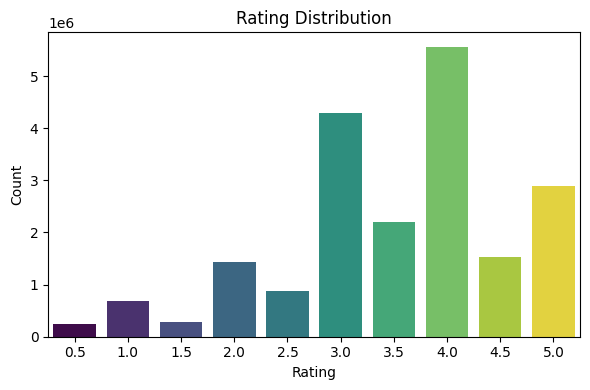

In [30]:
# Rating distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis', legend=False)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

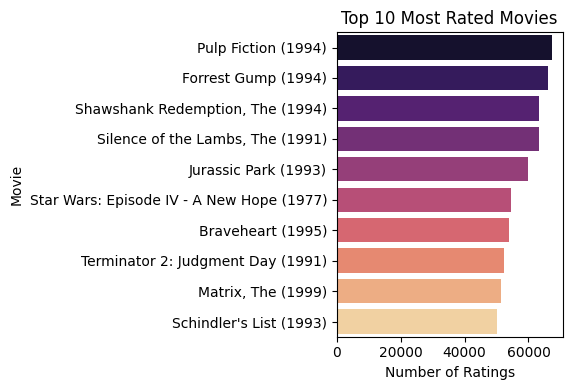

In [31]:
# Top 10 highest rated movies
top_rated = ratings.groupby('movieId')['rating'].count().reset_index()
top_rated.columns = ['movieId', 'rating_count']
top_rated = top_rated.merge(movies[['movieId', 'title']], on='movieId')
top_rated = top_rated.sort_values('rating_count', ascending=False).head(10)


plt.figure(figsize=(6,4))
sns.barplot(x='rating_count', y='title', data=top_rated, hue='title', palette='magma', legend=False)
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()

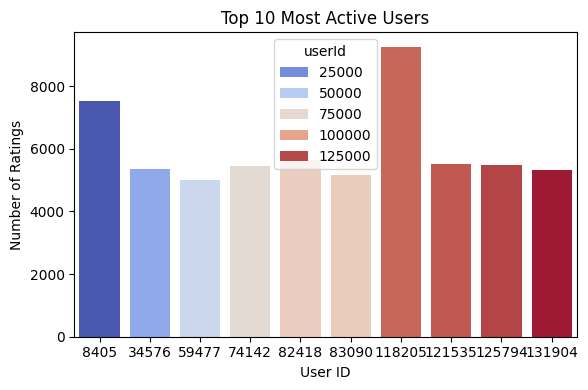

In [32]:
# Most active users
active_users = ratings.groupby('userId')['rating'].count().reset_index()
active_users.columns = ['userId', 'rating_count']
active_users = active_users.sort_values('rating_count', ascending=False).head(10)

plt.figure(figsize=(6,4))
sns.barplot(x='userId', y='rating_count', hue='userId', data=active_users, palette='coolwarm')
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

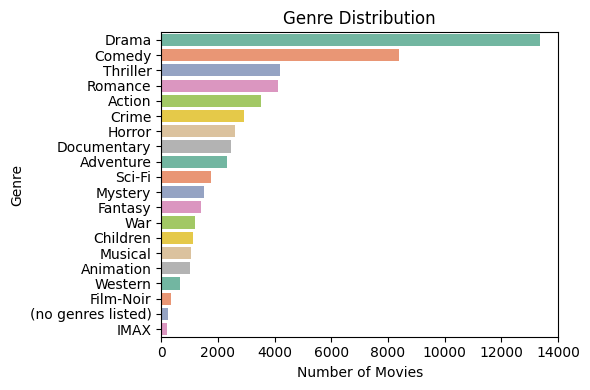

In [33]:
# Genre distribution
all_genres = [genre for sublist in movies['genres_list'] for genre in sublist]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['genre', 'count']).sort_values('count', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='count', y='genre', hue='genre', data=genre_df, palette='Set2')
plt.title('Genre Distribution')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

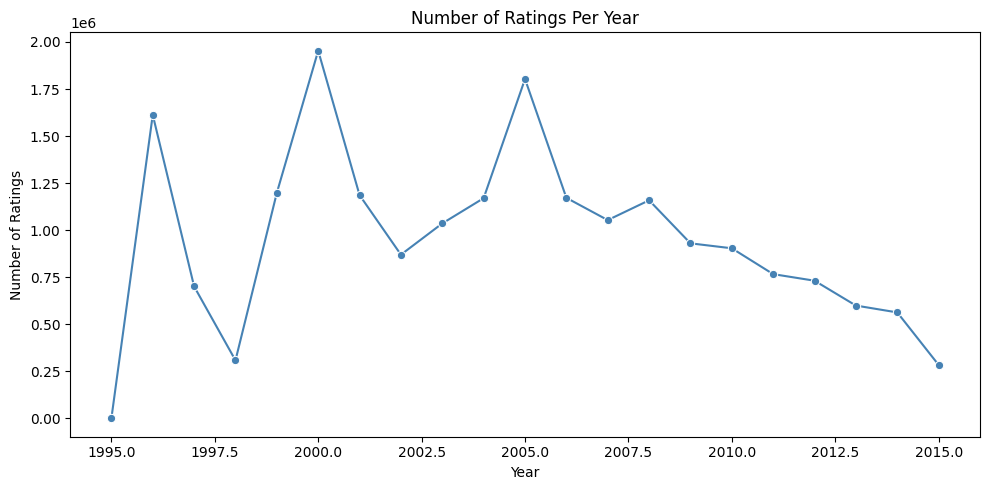

In [34]:
# Ratings over year
ratings['year'] = ratings['timestamp'].dt.year
ratings_per_year = ratings.groupby('year')['rating'].count().reset_index()
ratings_per_year.columns = ['year', 'rating_count']

plt.figure(figsize=(10, 5))
sns.lineplot(x='year', y='rating_count', data=ratings_per_year, marker='o', color='steelblue')
plt.title('Number of Ratings Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

Feature Engineering

In [35]:
# Grouping tags
movie_tags = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
movie_tags.columns = ['movieId', 'tags_combined']

# Merge tags with movies
movies = movies.merge(movie_tags, on='movieId', how='left')
movies['tags_combined'] = movies['tags_combined'].fillna('')

# Combine genres and tags into a single content profile
movies['content'] = movies['genres'].str.replace('|', ' ', regex=False) + ' ' + movies['tags_combined']

print("Movie profiles")
display(movies[['title', 'genres', 'tags_combined', 'content']].head())

Movie profiles


,title,genres,tags_combined,content
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Watched computer animation Disney animated fea...,Adventure Animation Children Comedy Fantasy Wa...
1,Jumanji (1995),Adventure|Children|Fantasy,time travel adapted from:book board game child...,Adventure Children Fantasy time travel adapted...
2,Grumpier Old Men (1995),Comedy|Romance,old people that is actually funny sequel fever...,Comedy Romance old people that is actually fun...
3,Waiting to Exhale (1995),Comedy|Drama|Romance,chick flick revenge characters chick flick cha...,Comedy Drama Romance chick flick revenge chara...
4,Father of the Bride Part II (1995),Comedy,Diane Keaton family sequel Steve Martin weddin...,Comedy Diane Keaton family sequel Steve Martin...


Term Frequency - Inverse Document Frequency (TF-IDF)

In [36]:
# TF-IDF(Term Frequency-Inverse Document Frequency)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['content'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Each movie is represented by {tfidf_matrix.shape[1]} features")

TF-IDF Matrix Shape: (27278, 23865)
Each movie is represented by 23865 features


Cosine Similarity

In [37]:
# Cosine simialrity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Cosine Similarity Matrix Shape: {cosine_sim.shape}")
print(f"This means we have similarity scores between all {cosine_sim.shape[0]} movies")

Cosine Similarity Matrix Shape: (27278, 27278)
This means we have similarity scores between all 27278 movies


Content Based Recommendation

In [38]:
# Create a mapping of movie title to index (without year, lowercase, no spaces)
movies['title_clean'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip().str.lower().str.replace(' ', '')

indices = pd.Series(movies.index, index=movies['title_clean']).drop_duplicates()

def content_based_recommend(title, n=10):
    # Clean the input the same way
    title_clean = title.strip().lower().replace(' ', '')

    # Check if movie exists
    if title_clean not in indices:
        print(f"❌ Movie '{title}' not found in dataset.")
        return

    # Get index of the movie — force single value
    idx = indices[title_clean]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Get similarity scores for this movie with all others
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top n most similar movies (excluding itself)
    sim_scores = sim_scores[1:n+1]

    # Get movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return recommended movies
    recommended = movies[['title', 'genres']].iloc[movie_indices].copy()
    recommended['similarity_score'] = [round(i[1], 4) for i in sim_scores]

    return recommended.reset_index(drop=True)

# Take user input
movie_name = input("🎬 Enter a movie name: ")
recommendations = content_based_recommend(movie_name, n=10)
if recommendations is not None:
    print(f"\n🎬 Movies similar to '{movie_name}':")
    display(recommendations)


🎬 Movies similar to 'toy story':


,title,genres,similarity_score
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.9356
1,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.8534
2,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.8079
3,Ice Age (2002),Adventure|Animation|Children|Comedy,0.7654
4,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.7624
5,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.7587
6,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy,0.7335
7,Ratatouille (2007),Animation|Children|Drama,0.7298
8,Tin Toy (1988),Animation|Children,0.6891
9,The Legend of Mor'du (2012),Animation|Children,0.6891


Filtering for Collaborative Recommendation

In [39]:
# Filter active users
active_users = ratings.groupby('userId')['rating'].count()
active_users = active_users[active_users >= 500].index

print(f"Active users : {len(active_users)}")

Active users : 7491


In [40]:
# Filter active movies
active_movies = ratings.groupby('movieId')['rating'].count()
active_movies = active_movies[active_movies >= 500].index

print(f"Active movies : {len(active_movies)}")

Active movies : 4489


In [41]:
# Filter ratings
ratings_filtered = ratings[
    ratings['userId'].isin(active_users) &
    ratings['movieId'].isin(active_movies)
]

print(f"Users  : {ratings_filtered['userId'].nunique()}")
print(f"Movies : {ratings_filtered['movieId'].nunique()}")

Users  : 7491
Movies : 4489


In [42]:
print(f"Users  : {len(active_users)}")
print(f"Movies : {len(active_movies)}")
print(f"Estimated matrix size : {len(active_users) * len(active_movies)} cells")

Users  : 7491
Movies : 4489
Estimated matrix size : 33627099 cells


In [74]:
users_count  = ratings_filtered['userId'].nunique()
movies_count = ratings_filtered['movieId'].nunique()
total_cells  = users_count * movies_count

print(f"Users        : {users_count}")
print(f"Movies       : {movies_count}")
print(f"Total cells  : {total_cells}")

Users        : 7491
Movies       : 4489
Total cells  : 33627099


Encoding User ID and Movie ID

In [44]:
# Matrix

# Encode userId and movieId as integer positions
user_ids  = ratings_filtered['userId'].astype('category')
movie_ids = ratings_filtered['movieId'].astype('category')

sparse_matrix = csr_matrix(
    (ratings_filtered['rating'].values,
    (user_ids.cat.codes, movie_ids.cat.codes))
)

print(f"Sparse matrix shape : {sparse_matrix.shape}")

Sparse matrix shape : (7491, 4489)


Cosine Similarity Matrix

In [45]:
user_similarity = cosine_similarity(sparse_matrix)

user_index = user_ids.cat.categories

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_index,
    columns=user_index
)

print(f"User similarity shape : {user_similarity_df.shape}")
display(user_similarity_df.head())

User similarity shape : (7491, 7491)


,11,24,54,58,91,104,116,134,156,208,...,138270,138301,138307,138325,138382,138397,138406,138411,138437,138474
11,1.000000,0.252699,0.222076,0.224909,0.314799,0.101248,0.355613,0.198066,0.230458,0.206414,...,0.162471,0.278013,0.260467,0.276396,0.237366,0.286474,0.320246,0.301959,0.336912,0.252902
24,0.252699,1.000000,0.361723,0.393981,0.398948,0.174909,0.431961,0.363594,0.402274,0.253775,...,0.401811,0.291583,0.290855,0.238213,0.339983,0.322599,0.286366,0.425133,0.267795,0.383350
54,0.222076,0.361723,1.000000,0.449139,0.396829,0.304493,0.373027,0.464965,0.502741,0.368866,...,0.408564,0.256702,0.340609,0.298168,0.501127,0.420116,0.283863,0.485531,0.233834,0.404863
58,0.224909,0.393981,0.449139,1.000000,0.454515,0.384234,0.356143,0.435620,0.455744,0.434361,...,0.455839,0.334070,0.424437,0.422272,0.385420,0.394994,0.364105,0.490721,0.323353,0.283678
91,0.314799,0.398948,0.396829,0.454515,1.000000,0.309391,0.445154,0.367634,0.396005,0.374019,...,0.380156,0.375136,0.371275,0.412180,0.347753,0.437759,0.386498,0.509853,0.361721,0.390698


Collaborative Recommendation Function

In [46]:
#Collaborative Recommendation function
def collaborative_recommend(user_id, n=10):

    # Check if user exists
    if user_id not in user_similarity_df.index:
        print(f"User {user_id} not found")
        return

    # Find similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)

    # Remove current user
    similar_users = similar_users.drop(user_id)

    # Get most similar user
    similar_user_id = similar_users.index[0]

    print(f"Most similar user to User {user_id}: User {similar_user_id}")

    # Movies watched by target user
    user_movies = set(
        ratings[ratings['userId'] == user_id]['movieId']
    )

    # Movies watched by similar user
    similar_user_movies = ratings[
        ratings['userId'] == similar_user_id
    ].sort_values('rating', ascending=False)

    # Remove movies already watched
    recommendations = similar_user_movies[
        ~similar_user_movies['movieId'].isin(user_movies)
    ]

    # Merge with movie titles
    recommendations = recommendations.merge(
        movies[['movieId', 'title', 'genres']],
        on='movieId'
    )

    # Return top recommendations
    return recommendations[
        ['title', 'genres', 'rating']
    ].head(n).reset_index(drop=True)

In [50]:
user_id = int(input("Enter User ID: "))

recommended_movies = collaborative_recommend(user_id)

display(recommended_movies)

Most similar user to User 91: User 80633


,title,genres,rating
0,Night of the Living Dead (1968),Horror|Sci-Fi|Thriller,5.0
1,Die Hard (1988),Action|Crime|Thriller,5.0
2,UHF (1989),Comedy,5.0
3,Halloween (1978),Horror,5.0
4,Lord of the Flies (1963),Adventure|Drama|Thriller,5.0
5,Mortal Kombat (1995),Action|Adventure|Fantasy,4.5
6,Stand by Me (1986),Adventure|Drama,4.5
7,Beverly Hills Cop (1984),Action|Comedy|Crime|Drama,4.5
8,"Castle, The (1997)",Comedy,4.5
9,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,4.5


IMDB Integration

In [51]:
links['imdb_url'] = 'https://www.imdb.com/title/tt' + links['imdbId'].astype(str).str.zfill(7)
movies = movies.merge(
    links[['movieId', 'imdb_url']],
    on='movieId',
    how='left'
)

In [52]:
display(movies[['title', 'imdb_url']].head())

,title,imdb_url
0,Toy Story (1995),https://www.imdb.com/title/tt0114709
1,Jumanji (1995),https://www.imdb.com/title/tt0113497
2,Grumpier Old Men (1995),https://www.imdb.com/title/tt0113228
3,Waiting to Exhale (1995),https://www.imdb.com/title/tt0114885
4,Father of the Bride Part II (1995),https://www.imdb.com/title/tt0113041


TMDB Integration

In [54]:
API_KEY = '7d005c5660340144edeb2be0dd95ba75'


def fetch_tmdb_data(tmdb_id):
    url = f'https://api.themoviedb.org/3/movie/{tmdb_id}?api_key={API_KEY}'
    response = requests.get(url)

    if response.status_code == 200:
        return response.json()
    else:
        return None

In [55]:
movie_title = input("Enter movie name: ")

search_url = f'https://api.themoviedb.org/3/search/movie?api_key={API_KEY}&query={movie_title}'
response = requests.get(search_url)

results = response.json().get('results', [])

if results:
    movie_data = results[0]
    poster_path = movie_data['poster_path']
    poster_url = 'https://image.tmdb.org/t/p/w500' + poster_path
    print(poster_url)
else:
    print("Movie not found.")

https://image.tmdb.org/t/p/w500/xlaY2zyzMfkhk0HSC5VUwzoZPU1.jpg


Ratings and Review Analysis: Sentiment Score

In [56]:
def get_sentiment_score(movie_id):
    movie_tags = tags[tags['movieId'] == movie_id]['tag'].dropna().tolist()
    if not movie_tags:
        return 0.0
    combined = ' '.join(movie_tags)
    return TextBlob(combined).sentiment.polarity

Hybrid Recommendation (Content Based and User Based Recommendation)

In [65]:
def hybrid_recommend(user_id, movie_title, n=10):

    # --- Content-Based ---
    content_recs = content_based_recommend(movie_title, n=30)
    if content_recs is None:
        return

    # --- Collaborative ---
    collab_recs = collaborative_recommend(user_id, n=30)
    if collab_recs is None:
        return

    # --- Normalize content similarity score (0 to 1) ---
    content_recs = content_recs.copy()
    max_score = content_recs['similarity_score'].max()
    content_recs['content_score'] = content_recs['similarity_score'] / max_score

    # --- Normalize collaborative rating score (0 to 1) ---
    collab_recs = collab_recs.copy()
    collab_recs['collab_score'] = collab_recs['rating'] / 5.0

    # --- Merge both ---
    merged = pd.merge(
        content_recs[['title', 'genres', 'content_score']],
        collab_recs[['title', 'collab_score']],
        on='title',
        how='outer'
    ).fillna(0)

    # --- Add sentiment score ---
    merged = merged.merge(
        movies[['title', 'movieId', 'genres']],
        on='title',
        how='left',
        suffixes=('', '_fixed')
    )
    merged['genres'] = np.where(
        merged['genres'] == 0, 
        merged['genres_fixed'], 
        merged['genres']
    )
    merged = merged.drop(columns=['genres_fixed'])
    merged['sentiment_score'] = merged['movieId'].apply(
        lambda x: get_sentiment_score(x) if pd.notna(x) else 0.0
    )

    # --- Final hybrid score (weighted blend) ---
    merged['hybrid_score'] = (
        0.5 * merged['content_score'] +
        0.3 * merged['collab_score'] +
        0.2 * merged['sentiment_score']
    )

    # --- Sort and return top n ---
    result = merged.sort_values('hybrid_score', ascending=False).head(n)
    return result[['title', 'genres', 'content_score', 'collab_score', 'sentiment_score', 'hybrid_score']].reset_index(drop=True)

TMDB Posters Integration

In [71]:
def display_recommendations_with_posters(result, movie_title):
    print(f"\n🎬 Hybrid Recommendations based on '{movie_title}':\n")

    html = '<div style="display:flex; flex-wrap:wrap; gap:15px;">'

    for _, row in result.iterrows():
        title  = row['title']
        genres = row['genres']
        score  = round(row['hybrid_score'], 3)

        # Get tmdbId from links using movieId
        movie_row = movies[movies['title'] == title]
        poster_url = 'https://via.placeholder.com/200x300?text=No+Poster'

        if not movie_row.empty:
            movie_id = movie_row.iloc[0]['movieId']
            link_row = links[links['movieId'] == movie_id]

            if not link_row.empty:
                tmdb_id = link_row.iloc[0]['tmdbId']

                if pd.notna(tmdb_id):
                    tmdb_url = f'https://api.themoviedb.org/3/movie/{int(tmdb_id)}?api_key={API_KEY}'
                    response = requests.get(tmdb_url)

                    if response.status_code == 200:
                        data = response.json()
                        path = data.get('poster_path')
                        if path:
                            poster_url = 'https://image.tmdb.org/t/p/w200' + path

        html += f'''
        <div style="width:160px; text-align:center; font-family:Arial; font-size:12px;">
            <img src="{poster_url}" width="150" height="220" style="border-radius:8px;"/><br/>
            <b>{title}</b><br/>
            <span style="color:gray;">{genres}</span><br/>
            <span style="color:green;">Score: {score}</span>
        </div>
        '''

    html += '</div>'
    display(HTML(html))

Testing and Result

In [72]:
user_id     = int(input("Enter User ID: "))
movie_title = input("Enter Movie Title: ")

result = hybrid_recommend(user_id, movie_title, n=10)

if result is not None:
    display_recommendations_with_posters(result, movie_title)

Most similar user to User 91: User 80633

🎬 Hybrid Recommendations based on 'Toy Story':

